<a href="https://colab.research.google.com/github/Dapaaj/Dis_predic/blob/main/pythonmlmodels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ============================================================
# 1. INSTALL LIBRARIES
# ============================================================
# Installs all required packages for Colab.
!pip install -q ucimlrepo tensorflow xgboost deap catboost

In [9]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================
import numpy as np
import pandas as pd
import random


import matplotlib.pyplot as plt
import seaborn as sns


from ucimlrepo import fetch_ucirepo


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    cohen_kappa_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA


from xgboost import XGBClassifier
from catboost import CatBoostClassifier


from deap import base, creator, tools, algorithms


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [10]:
# ============================================================
# 3. LOAD UCI HEART DISEASE DATA
# ============================================================


heart = fetch_ucirepo(id=45)  # Cleveland heart disease dataset

X_raw = heart.data.features
y_raw = heart.data.targets

df = pd.concat([X_raw, y_raw], axis=1)

print("Raw dataset shape:", df.shape)
display(df.head())

Raw dataset shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [11]:
# ============================================================
# 4. CLEAN TARGET + HANDLE MISSING VALUES
# ============================================================
# Convert target to binary:
# 0 = no disease, 1 = disease present
df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

print("Target value counts:\n", df["num"].value_counts())

# Replace '?' with NaN and convert everything to numeric
df = df.replace("?", np.nan)
df = df.apply(pd.to_numeric, errors="coerce")

print("\nMissing values after numeric conversion:\n", df.isnull().sum())

# Impute missing values in ca and thal with mode
df["ca"] = df["ca"].fillna(df["ca"].mode()[0])
df["thal"] = df["thal"].fillna(df["thal"].mode()[0])

print("\nMissing values after imputation:\n", df.isnull().sum())

Target value counts:
 num
0    164
1    139
Name: count, dtype: int64

Missing values after numeric conversion:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Missing values after imputation:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


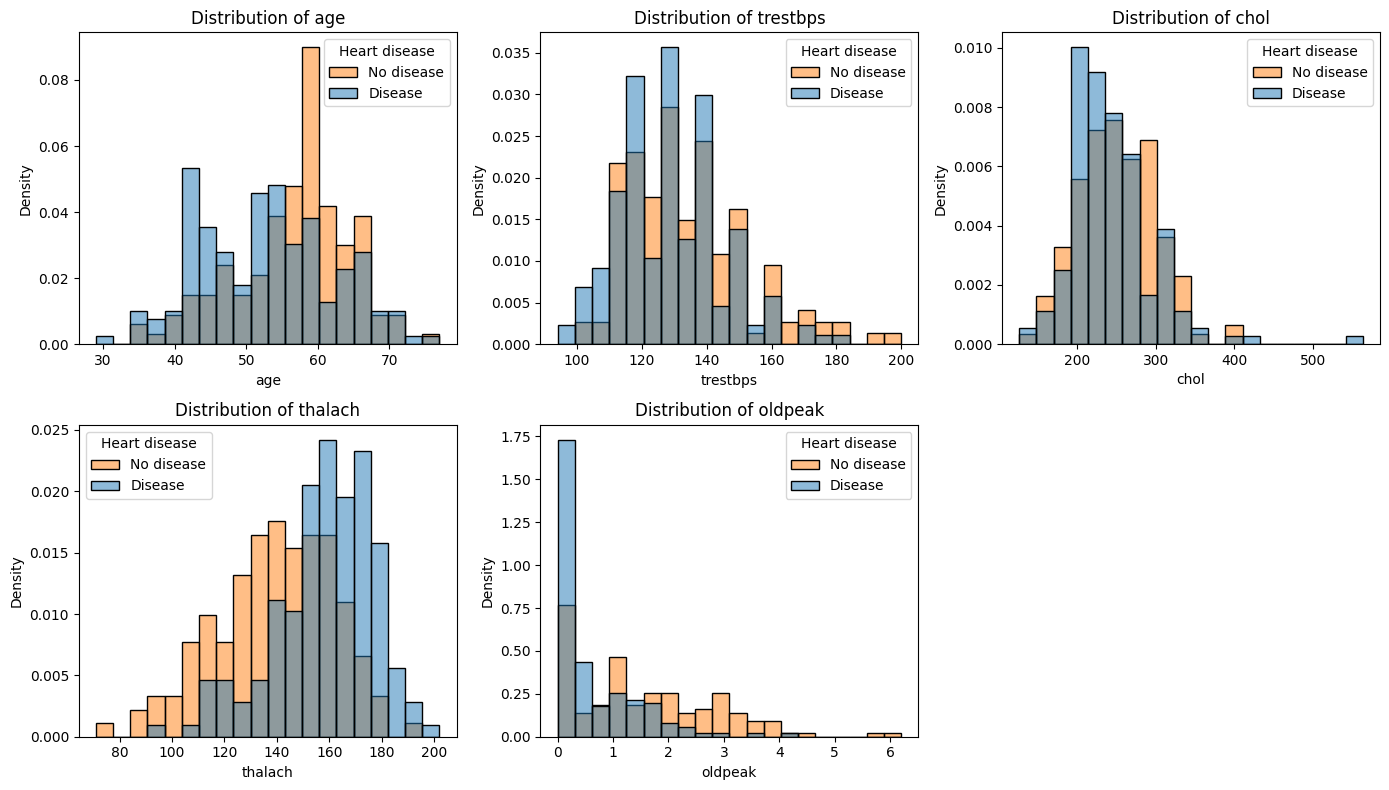

In [12]:
# ============================================================
# A. HISTOGRAMS OF NUMERIC FEATURES (BY HEART DISEASE STATUS)
# ============================================================
numeric_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    # Overlay histograms for no-disease vs disease
    sns.histplot(
        data=df,
        x=col,
        hue="num",           # 0 = no disease, 1 = disease
        bins=20,
        kde=False,
        stat="density",
        common_norm=False,
        palette={0: "tab:blue", 1: "tab:orange"}
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend(title="Heart disease", labels=["No disease", "Disease"])

plt.tight_layout()
plt.show()

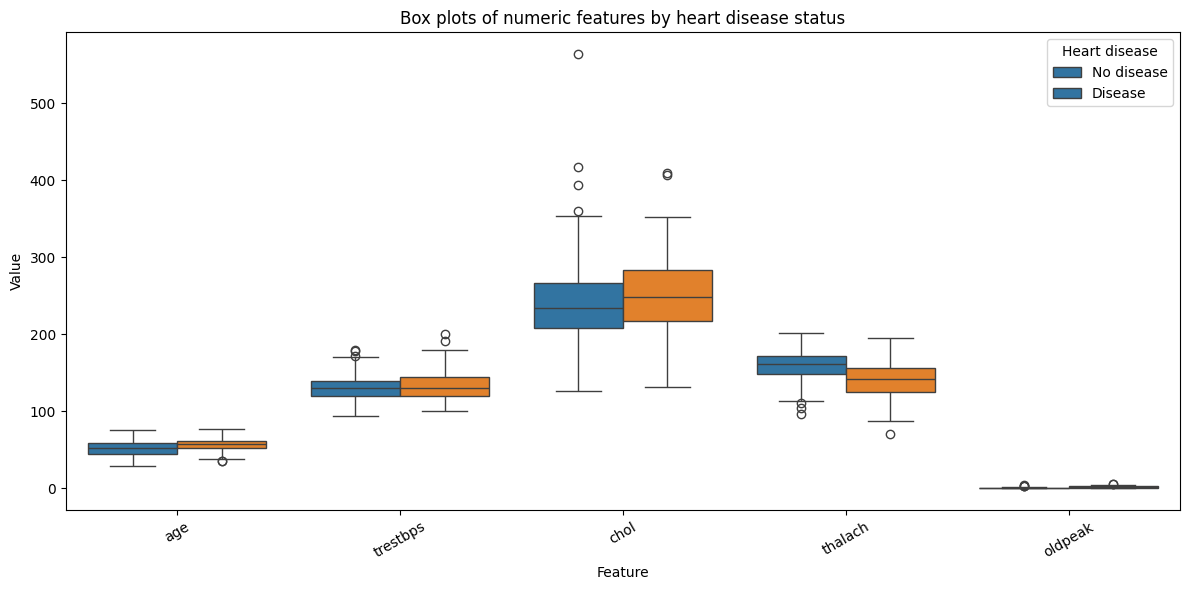

In [13]:
# ============================================================
# B. BOX PLOTS OF NUMERIC FEATURES BY HEART DISEASE STATUS
# ============================================================
plt.figure(figsize=(12, 6))

df_long = df.melt(
    id_vars="num",
    value_vars=numeric_cols,
    var_name="Feature",
    value_name="Value"
)

sns.boxplot(
    data=df_long,
    x="Feature",
    y="Value",
    hue="num",
    palette={0: "tab:blue", 1: "tab:orange"}
)

plt.xlabel("Feature")
plt.ylabel("Value")
plt.title("Box plots of numeric features by heart disease status")
plt.legend(title="Heart disease", labels=["No disease", "Disease"])
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

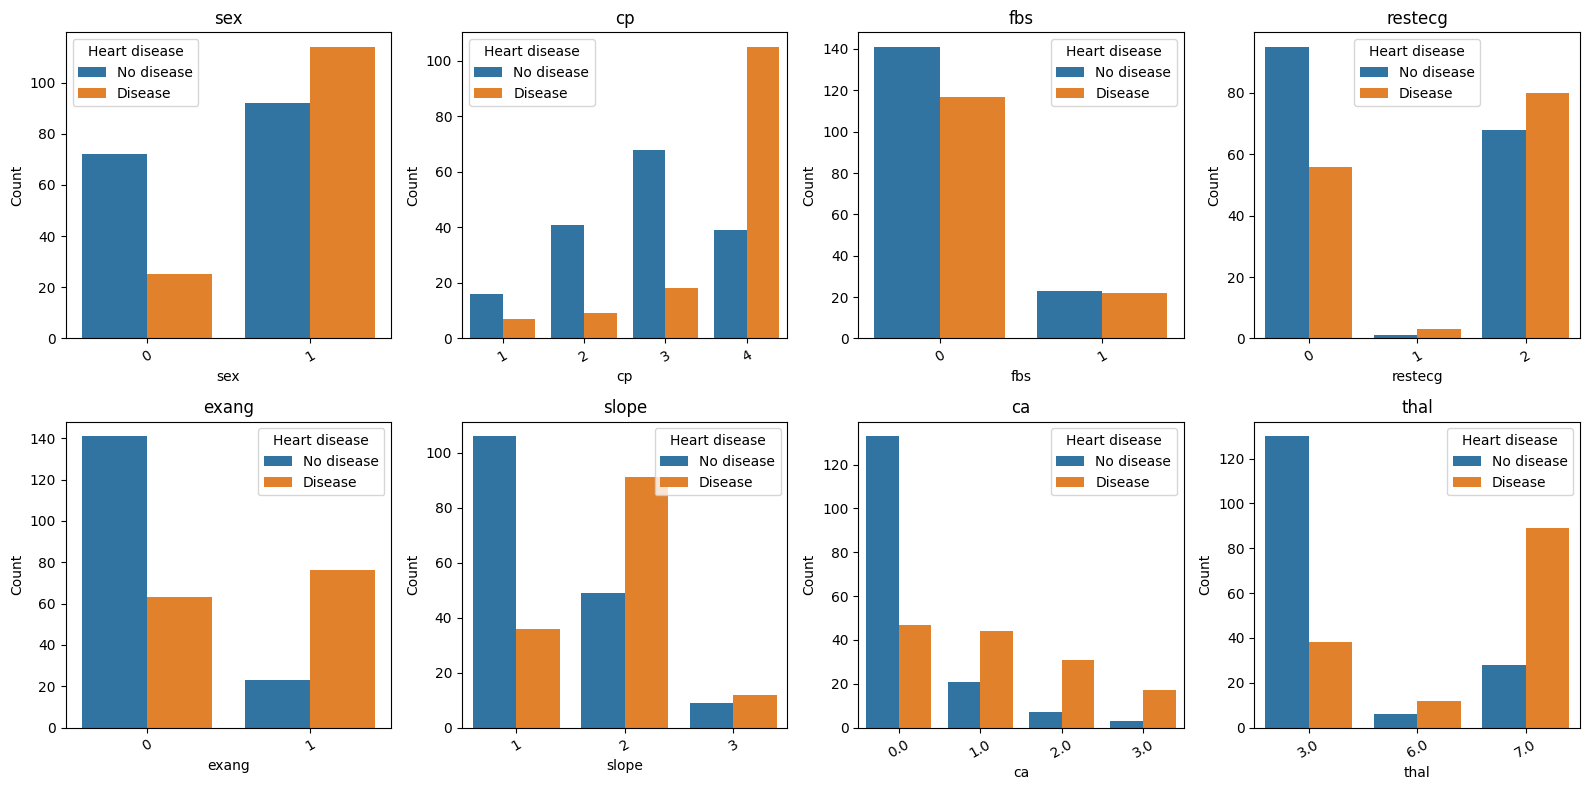

In [14]:
# ============================================================
# C. COUNT PLOTS FOR CATEGORICAL FEATURES
# ============================================================
categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

n_cols = 4
n_rows = int(np.ceil(len(categorical_cols) / n_cols))

plt.figure(figsize=(16, 8))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(
        data=df,
        x=col,
        hue="num",
        palette={0: "tab:blue", 1: "tab:orange"}
    )
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Heart disease", labels=["No disease", "Disease"])
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Full correlation matrix (features + target 'num'):

               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.097542  0.104139  0.284946  0.208950  0.118530   
sex      -0.097542  1.000000  0.010084 -0.064456 -0.199915  0.047862   
cp        0.104139  0.010084  1.000000 -0.036077  0.072319 -0.039975   
trestbps  0.284946 -0.064456 -0.036077  1.000000  0.130120  0.175340   
chol      0.208950 -0.199915  0.072319  0.130120  1.000000  0.009841   
fbs       0.118530  0.047862 -0.039975  0.175340  0.009841  1.000000   
restecg   0.148868  0.021647  0.067505  0.146560  0.171043  0.069564   
thalach  -0.393806 -0.048663 -0.334422 -0.045351 -0.003432 -0.007854   
exang     0.091661  0.146201  0.384060  0.064762  0.061310  0.025665   
oldpeak   0.203805  0.102173  0.202277  0.189171  0.046564  0.005747   
slope     0.161770  0.037533  0.152050  0.117382 -0.004062  0.059894   
ca        0.365323  0.086048  0.233117  0.097528  0.123726  0.140764   
thal      0.

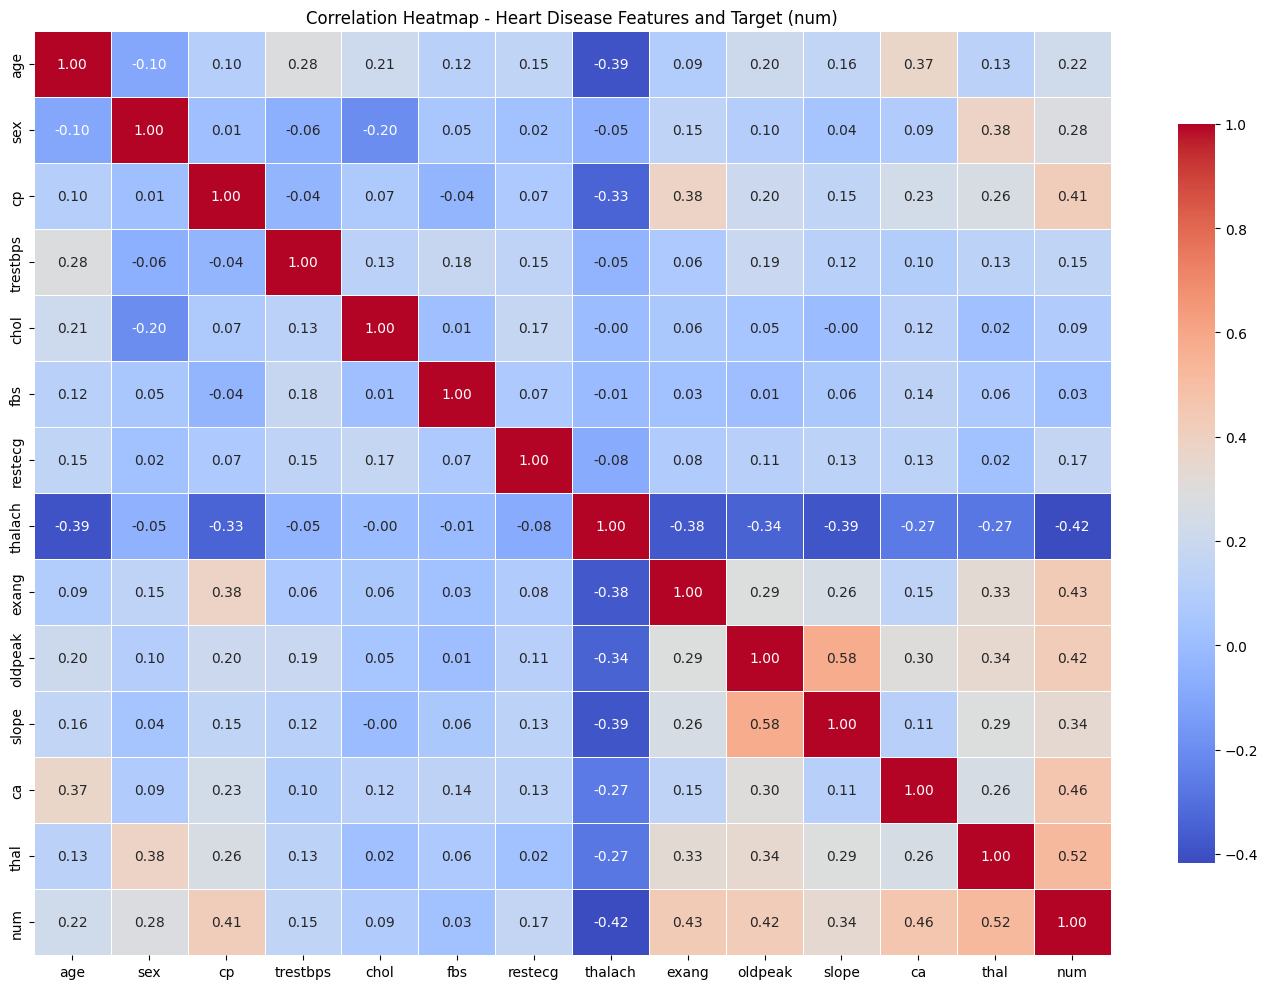

In [15]:
# ============================================================
# CORRELATION MATRIX + HEATMAP (CLEANED DATA)
# ============================================================

# Define X and y from the cleaned dataframe (df) for this correlation analysis
X = df.drop("num", axis=1)
y = df["num"]

corr_df = pd.concat([X, y], axis=1)

# Compute correlation matrix
corr_matrix = corr_df.corr()

# 1) Print full correlation matrix
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
print("Full correlation matrix (features + target 'num'):\n")
print(corr_matrix)

# 2) Save numbers to CSV for later inspection
corr_matrix.to_csv("correlation_matrix_heart.csv")

# 3) Heatmap (optional visual)
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,      # now show the numbers in the heatmap cells
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap - Heart Disease Features and Target (num)")
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 5. ENCODING CATEGORICAL VARIABLES + SCALING NUMERIC ONES
# ============================================================
X = df.drop("num", axis=1)
y = df["num"]

categorical_cols = [
    "sex", "cp", "fbs",
    "restecg", "exang",
    "slope", "ca", "thal"
]

numeric_cols = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# One-hot encoding for categorical variables
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Shape after encoding:", X.shape)

# Standardize numeric features
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("Final feature matrix shape:", X.shape)
print("Total missing after preprocessing:", X.isnull().sum().sum())

clean_df = pd.concat([X, y], axis=1)
clean_df.to_csv("heart_cleaned.csv", index=False)


Shape after encoding: (303, 20)
Final feature matrix shape: (303, 20)
Total missing after preprocessing: 0


In [17]:
# ============================================================
# 6. EXTRA SPLIT FOR PCA-BASED EXPERIMENT
# ============================================================
X_train_pca_full, X_test_pca_full, y_train_pca, y_test_pca = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("PCA train/test shapes (full features):",
      X_train_pca_full.shape, X_test_pca_full.shape)

PCA train/test shapes (full features): (242, 20) (61, 20)


In [18]:
# ============================================================
# 7. TRAIN-TEST SPLIT + RF-BASED FEATURE SELECTION
# ============================================================
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set (full features):", X_train_full.shape)
print("Test set (full features):", X_test_full.shape)

# Use Random Forest to rank features by importance
fs_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
fs_rf.fit(X_train_full, y_train)

importances = fs_rf.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 15 features by RF importance:")
print(feat_imp_df.head(15))

# Select top-k features
k = 14
top_features = feat_imp_df["feature"].iloc[:k].tolist()

print(f"\nUsing top {k} features:")
print(top_features)

X_train = X_train_full[top_features].copy()
X_test = X_test_full[top_features].copy()

print("\nTraining set (selected features):", X_train.shape)
print("Test set (selected features):", X_test.shape)

selected_df = pd.concat([X[top_features], y], axis=1)
selected_df.to_csv("heart_selected_features.csv", index=False)


Training set (full features): (242, 20)
Test set (full features): (61, 20)

Top 15 features by RF importance:
      feature  importance
3     thalach    0.135746
19   thal_7.0    0.113223
4     oldpeak    0.103921
0         age    0.096305
8        cp_4    0.096171
2        chol    0.087608
1    trestbps    0.080917
12    exang_1    0.050464
5       sex_1    0.043650
13    slope_2    0.038568
15     ca_1.0    0.037001
11  restecg_2    0.023529
7        cp_3    0.020903
16     ca_2.0    0.019037
6        cp_2    0.014706

Using top 14 features:
['thalach', 'thal_7.0', 'oldpeak', 'age', 'cp_4', 'chol', 'trestbps', 'exang_1', 'sex_1', 'slope_2', 'ca_1.0', 'restecg_2', 'cp_3', 'ca_2.0']

Training set (selected features): (242, 14)
Test set (selected features): (61, 14)


In [19]:
# ============================================================
# 8. HELPER PLOTTING & EVALUATION FUNCTIONS
# ============================================================
def compute_binary_metrics(y_true, y_pred, y_score=None, positive_label=1):
    """
    Compute a full set of binary classification metrics.
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, positive_label])
    tn, fp, fn, tp = cm.ravel()
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    sd = float(np.array([accuracy, precision, recall, f1], dtype=float).std())
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=positive_label)
        roc_auc = auc(fpr, tpr)
        pr_precision, pr_recall, _ = precision_recall_curve(y_true, y_score, pos_label=positive_label)
        auprc = auc(pr_recall, pr_precision)
    else:
        roc_auc = None
        auprc = None
    return {
        "Accuracy": accuracy, "Precision": precision, "Recall": recall,
        "F1-score": f1, "Specificity": specificity, "SD": sd,
        "Kappa": kappa, "MCC": mcc, "AUC": roc_auc, "AUPRC": auprc
    }

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=["No disease", "Disease"], yticklabels=["No disease", "Disease"])
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(title); plt.tight_layout(); plt.show()

def plot_roc_curve_generic(y_true, y_score, title):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(4, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title(title); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

def plot_pr_curve(y_true, y_score, title):
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_score)
    auprc = auc(recall_curve, precision_curve)
    plt.figure(figsize=(4, 4))
    plt.plot(recall_curve, precision_curve, label=f"AUPRC = {auprc:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title(title); plt.legend(loc="lower left"); plt.tight_layout(); plt.show()

def plot_training_history(history, title):
    plt.figure(figsize=(5, 4))
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

Framingham-like baseline metrics:
Accuracy: 0.689
Precision: 0.696
Recall: 0.571
F1-score: 0.627
Specificity: 0.788
SD: 0.050
Kappa: 0.364
MCC: 0.369
AUC: 0.814
AUPRC: 0.780


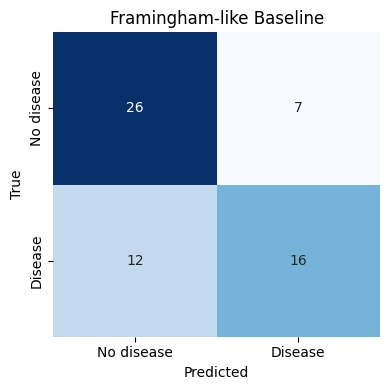

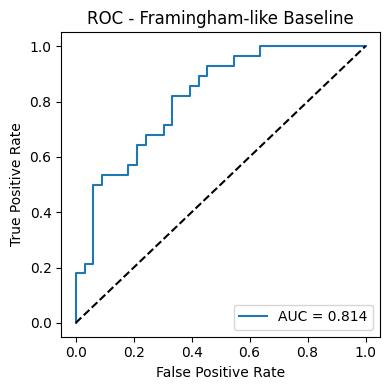

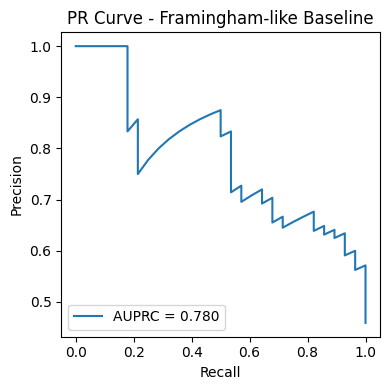

In [20]:
# ============================================================
# 7b. FRAMINGHAM-LIKE BASELINE (RESTRICTED LOGISTIC REGRESSION)
# ============================================================

# Use only Framingham-style risk factors (approximate, limited by Cleveland variables)
# Note: 'sex' became 'sex_1' after one-hot encoding in section 5
framingham_like_features = ["age", "sex_1", "trestbps", "chol", "thalach"]

X_train_fram = X_train_full[framingham_like_features].copy()
X_test_fram = X_test_full[framingham_like_features].copy()

# Fit a simple logistic regression on these limited predictors
fram_log_reg = LogisticRegression(max_iter=1000, random_state=42)
fram_log_reg.fit(X_train_fram, y_train)

# Predicted probabilities and labels
y_score_fram = fram_log_reg.predict_proba(X_test_fram)[:, 1]
y_pred_fram = (y_score_fram >= 0.5).astype(int)  # threshold can be varied

# Evaluate using your generic metrics function (defined in section 8)
fram_metrics = compute_binary_metrics(y_test, y_pred_fram, y_score_fram)
print("Framingham-like baseline metrics:")
for k, v in fram_metrics.items():
    print(f"{k}: {v:.3f}" if v is not None else f"{k}: {v}")

# Optional plots
cm_fram = confusion_matrix(y_test, y_pred_fram)
plot_confusion_matrix(cm_fram, "Framingham-like Baseline")
plot_roc_curve_generic(y_test, y_score_fram, "ROC - Framingham-like Baseline")
plot_pr_curve(y_test, y_score_fram, "PR Curve - Framingham-like Baseline")

Running Genetic Algorithm feature selection...
gen	nevals	avg     	max     
0  	30    	0.766454	0.834568
1  	18    	0.790039	0.834568
2  	11    	0.811824	0.834568
3  	19    	0.818937	0.834568
4  	24    	0.825801	0.834568
5  	21    	0.833745	0.834568
6  	11    	0.831005	0.834568
7  	23    	0.827008	0.834568
8  	16    	0.830053	0.834568
9  	19    	0.829494	0.834568
10 	18    	0.831415	0.834568
11 	16    	0.829072	0.834568
12 	13    	0.830729	0.834568
13 	7     	0.833194	0.834568
14 	21    	0.83154 	0.834568
15 	14    	0.834429	0.834568
16 	19    	0.8343  	0.834568
17 	26    	0.832918	0.834568
18 	21    	0.829084	0.834568
19 	22    	0.828234	0.834568
20 	21    	0.833059	0.834568

GA selected 11 features:
['sex_1', 'cp_2', 'cp_3', 'fbs_1', 'exang_1', 'slope_3', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_6.0', 'thal_7.0']
Best GA CV accuracy: 0.8346

GA + Logistic Regression test accuracy: 0.8688524590163934

GA + Logistic Regression classification report:
               precision    recall  f1-sc

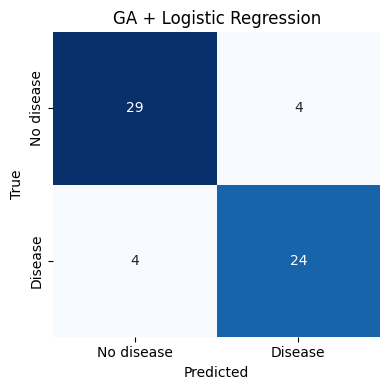

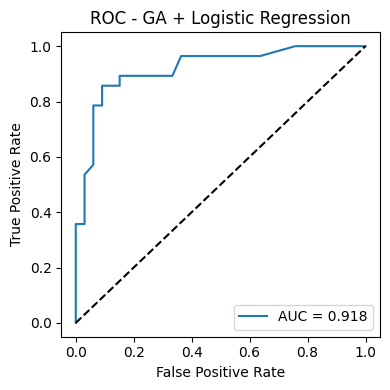

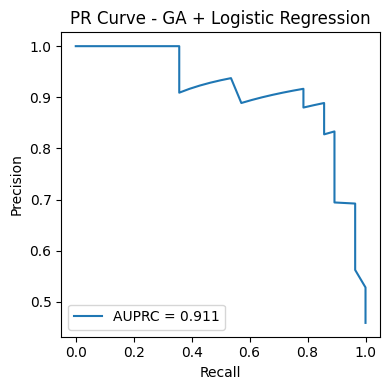

In [21]:
# ============================================================
# 9. GENETIC ALGORITHM FEATURE SELECTION
# ============================================================
X_train_ga_np = np.asarray(X_train_full, dtype="float32")
y_train_ga_np = np.asarray(y_train, dtype="int")
n_features_total = X_train_ga_np.shape[1]

def evaluate_individual(individual):
    """Evaluate one GA chromosome using CV accuracy."""
    cols = [i for i, bit in enumerate(individual) if bit == 1]
    if len(cols) == 0:
        return (0.0,)
    X_sub = X_train_ga_np[:, cols]
    clf = LogisticRegression(max_iter=300, random_state=42)
    scores = cross_val_score(clf, X_sub, y_train_ga_np, cv=3, scoring="accuracy")
    return (scores.mean(),)

# Reset DEAP creators if rerunning
if "FitnessMax" in creator.__dict__:
    del creator.FitnessMax
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n_features_total)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate_individual)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)

random.seed(42)
population = toolbox.population(n=30)
NGEN = 20
CXPB = 0.5
MUTPB = 0.2

hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)

print("Running Genetic Algorithm feature selection...")
pop, log = algorithms.eaSimple(
    population, toolbox,
    cxpb=CXPB, mutpb=MUTPB,
    ngen=NGEN, stats=stats, halloffame=hof,
    verbose=True
)

best_individual = hof[0]
ga_selected_cols_idx = [i for i, bit in enumerate(best_individual) if bit == 1]
ga_selected_features = [list(X.columns)[i] for i in ga_selected_cols_idx]

print(f"\nGA selected {len(ga_selected_features)} features:")
print(ga_selected_features)
print(f"Best GA CV accuracy: {best_individual.fitness.values[0]:.4f}")

X_train_ga = X_train_full[ga_selected_features].copy()
X_test_ga = X_test_full[ga_selected_features].copy()

ga_log_reg = LogisticRegression(max_iter=1000, random_state=42)
ga_log_reg.fit(X_train_ga, y_train)

y_pred_ga = ga_log_reg.predict(X_test_ga)
y_score_ga = ga_log_reg.predict_proba(X_test_ga)[:, 1]

print("\nGA + Logistic Regression test accuracy:", accuracy_score(y_test, y_pred_ga))
print("\nGA + Logistic Regression classification report:\n", classification_report(y_test, y_pred_ga))

cm_ga = confusion_matrix(y_test, y_pred_ga)
plot_confusion_matrix(cm_ga, "GA + Logistic Regression")
plot_roc_curve_generic(y_test, y_score_ga, "ROC - GA + Logistic Regression")
plot_pr_curve(y_test, y_score_ga, "PR Curve - GA + Logistic Regression")


Total explained variance ratio (PCA): 0.8460051057199363
Best Logistic Regression (PCA) params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
PCA + Logistic Regression test accuracy: 0.8852459016393442

PCA + Logistic Regression classification report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



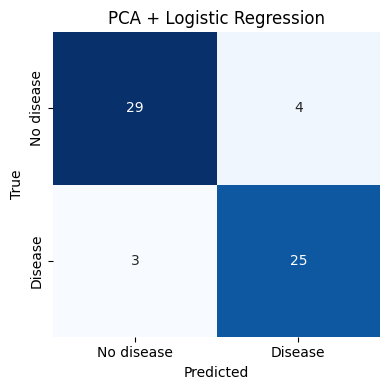

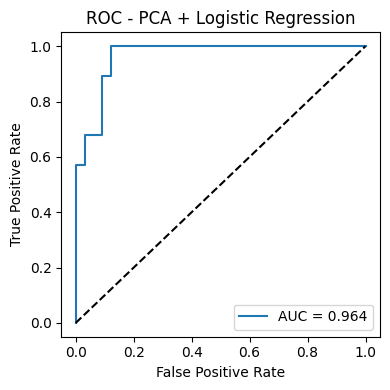

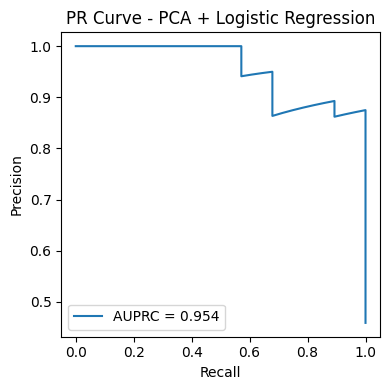

In [22]:
# ============================================================
# 10. PCA + LOGISTIC REGRESSION
# ============================================================
n_components = 8

pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_pca_full)
X_test_pca = pca.transform(X_test_pca_full)

print("Total explained variance ratio (PCA):", pca.explained_variance_ratio_.sum())

log_reg_pca = LogisticRegression(max_iter=1000, random_state=42)
log_param_grid_pca = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

log_grid_pca = GridSearchCV(
    estimator=log_reg_pca,
    param_grid=log_param_grid_pca,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

log_grid_pca.fit(X_train_pca, y_train_pca)
print("Best Logistic Regression (PCA) params:", log_grid_pca.best_params_)

best_log_pca = log_grid_pca.best_estimator_
y_pred_lr_pca = best_log_pca.predict(X_test_pca)
y_score_lr_pca = best_log_pca.predict_proba(X_test_pca)[:, 1]

print("PCA + Logistic Regression test accuracy:", accuracy_score(y_test_pca, y_pred_lr_pca))
print("\nPCA + Logistic Regression classification report:\n", classification_report(y_test_pca, y_pred_lr_pca))

cm_lr_pca = confusion_matrix(y_test_pca, y_pred_lr_pca)
plot_confusion_matrix(cm_lr_pca, "PCA + Logistic Regression")
plot_roc_curve_generic(y_test_pca, y_score_lr_pca, "ROC - PCA + Logistic Regression")
plot_pr_curve(y_test_pca, y_score_lr_pca, "PR Curve - PCA + Logistic Regression")


In [23]:
# ============================================================
# 11. CLASSICAL ML MODELS ON RF-SELECTED FEATURES
# ============================================================

# Logistic Regression
log_reg_base = LogisticRegression(max_iter=1000, random_state=42)
log_param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

log_grid = GridSearchCV(
    estimator=log_reg_base,
    param_grid=log_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

log_grid.fit(X_train, y_train)
print("Best Logistic Regression (RF features) params:", log_grid.best_params_)

log_reg = log_grid.best_estimator_
y_pred_lr = log_reg.predict(X_test)
y_score_lr = log_reg.predict_proba(X_test)[:, 1]

# SVM
svm_base = SVC(kernel="rbf", probability=True, random_state=42)
svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1]
}

svm_grid = GridSearchCV(
    estimator=svm_base,
    param_grid=svm_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)
print("Best SVM params:", svm_grid.best_params_)

svm_clf = svm_grid.best_estimator_
y_pred_svm = svm_clf.predict(X_test)
y_score_svm = svm_clf.predict_proba(X_test)[:, 1]

# Naive Bayes
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)
y_pred_nb = nb_clf.predict(X_test)
y_score_nb = nb_clf.predict_proba(X_test)[:, 1]

# AdaBoost
ada_base = AdaBoostClassifier(random_state=42)
ada_param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0]
}

ada_grid = GridSearchCV(
    estimator=ada_base,
    param_grid=ada_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

ada_grid.fit(X_train, y_train)
print("Best AdaBoost params:", ada_grid.best_params_)

ada_clf = ada_grid.best_estimator_
y_pred_ada = ada_clf.predict(X_test)
y_score_ada = ada_clf.predict_proba(X_test)[:, 1]


Best Logistic Regression (RF features) params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best SVM params: {'C': 100, 'gamma': 0.01}
Best AdaBoost params: {'learning_rate': 0.1, 'n_estimators': 50}


LVQ test accuracy: 0.8852459016393442

LVQ classification report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



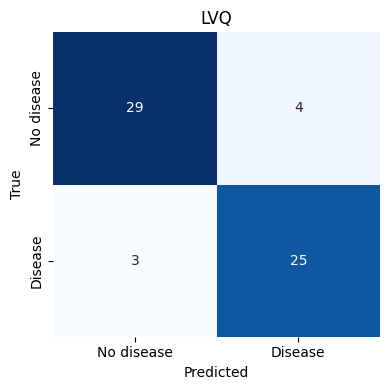

In [24]:
# ============================================================
# 12. LVQ PROTOTYPE-BASED CLASSIFIER
# ============================================================
class LVQ1:
    def __init__(self, n_prototypes_per_class=2, learning_rate=0.01, n_epochs=50, random_state=42):
        self.n_prototypes_per_class = n_prototypes_per_class
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state
        self.prototypes_ = None
        self.prototype_labels_ = None

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)

        classes = np.unique(y)
        prototypes = []
        proto_labels = []

        for c in classes:
            X_c = X[y == c]
            if X_c.shape[0] < self.n_prototypes_per_class:
                idx = rng.choice(X_c.shape[0], self.n_prototypes_per_class, replace=True)
            else:
                idx = rng.choice(X_c.shape[0], self.n_prototypes_per_class, replace=False)
            prototypes.append(X_c[idx])
            proto_labels.extend([c] * self.n_prototypes_per_class)

        self.prototypes_ = np.vstack(prototypes)
        self.prototype_labels_ = np.array(proto_labels)

        for epoch in range(self.n_epochs):
            indices = rng.permutation(X.shape[0])
            for i in indices:
                xi = X[i]
                yi = y[i]
                dists = np.linalg.norm(self.prototypes_ - xi, axis=1)
                j = np.argmin(dists)
                if self.prototype_labels_[j] == yi:
                    self.prototypes_[j] += self.learning_rate * (xi - self.prototypes_[j])
                else:
                    self.prototypes_[j] -= self.learning_rate * (xi - self.prototypes_[j])

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        dists = np.linalg.norm(self.prototypes_[None, :, :] - X[:, None, :], axis=2)
        nearest = np.argmin(dists, axis=1)
        return self.prototype_labels_[nearest]


# Train and evaluate LVQ.
lvq_model = LVQ1(n_prototypes_per_class=2, learning_rate=0.01, n_epochs=50, random_state=42)
lvq_model.fit(X_train, y_train)

y_pred_lvq = lvq_model.predict(X_test)

print("LVQ test accuracy:", accuracy_score(y_test, y_pred_lvq))
print("\nLVQ classification report:\n", classification_report(y_test, y_pred_lvq))

cm_lvq = confusion_matrix(y_test, y_pred_lvq)
plot_confusion_matrix(cm_lvq, "LVQ")

In [25]:
# ============================================================
# 13. RANDOM FOREST AND XGBOOST (TUNED)
# ============================================================

# -------------------------------
# Random Forest
# -------------------------------
rf = RandomForestClassifier(random_state=42)
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
print("Best Random Forest params:", rf_grid.best_params_)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_score_rf = best_rf.predict_proba(X_test)[:, 1]


# -------------------------------
# XGBoost
# -------------------------------
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)
print("Best XGBoost params:", xgb_grid.best_params_)

xgb_model = xgb_grid.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)
y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]

Best Random Forest params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best XGBoost params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 1.0}


In [26]:
# ============================================================
# 14. EXTRATREES AND CATBOOST
# ============================================================

# Extra Trees
et_base = ExtraTreesClassifier(random_state=42, n_jobs=-1)
et_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

et_grid = GridSearchCV(
    estimator=et_base,
    param_grid=et_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

et_grid.fit(X_train, y_train)
print("Best Extra Trees params:", et_grid.best_params_)

best_et = et_grid.best_estimator_
y_pred_et = best_et.predict(X_test)
y_score_et = best_et.predict_proba(X_test)[:, 1]

# CatBoost
cb_base = CatBoostClassifier(verbose=0, random_state=42)
cb_param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.1]
}

cb_grid = GridSearchCV(
    estimator=cb_base,
    param_grid=cb_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

cb_grid.fit(X_train, y_train)
print("Best CatBoost params:", cb_grid.best_params_)

best_cb = cb_grid.best_estimator_
y_pred_cb = best_cb.predict(X_test)
y_score_cb = best_cb.predict_proba(X_test)[:, 1]

Best Extra Trees params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CatBoost params: {'depth': 4, 'iterations': 100, 'learning_rate': 0.1}


Voting Ensemble Accuracy: 0.9180327868852459
Voting Ensemble AUC: 0.9577922077922079

Voting Ensemble classification report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.87      0.96      0.92        28

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



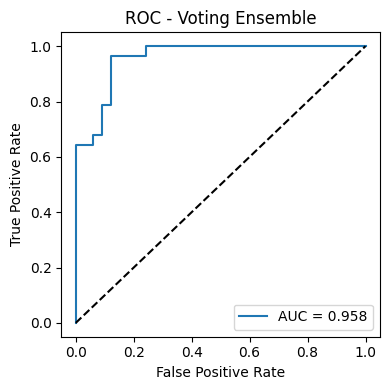

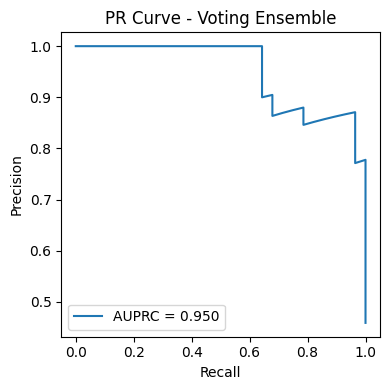

In [27]:
# ============================================================
# 15. VOTING ENSEMBLE
# ============================================================
voting_clf = VotingClassifier(
    estimators=[
        ("lr", log_reg),
        ("et", best_et),
        ("rf", best_rf),
        ("cb", best_cb),
        ("xgb", xgb_model)
    ],
    voting="soft",
    n_jobs=-1
)

voting_clf.fit(X_train, y_train)

y_pred_vote = voting_clf.predict(X_test)
y_score_vote = voting_clf.predict_proba(X_test)[:, 1]

print("Voting Ensemble Accuracy:", accuracy_score(y_test, y_pred_vote))
print("Voting Ensemble AUC:", roc_auc_score(y_test, y_score_vote))
print("\nVoting Ensemble classification report:\n", classification_report(y_test, y_pred_vote))

plot_roc_curve_generic(y_test, y_score_vote, "ROC - Voting Ensemble")
plot_pr_curve(y_test, y_score_vote, "PR Curve - Voting Ensemble")


Stacking Ensemble Accuracy: 0.8852459016393442
Stacking Ensemble AUC: 0.9632034632034632

Stacking Ensemble classification report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.86      0.89      0.88        28

    accuracy                           0.89        61
   macro avg       0.88      0.89      0.88        61
weighted avg       0.89      0.89      0.89        61



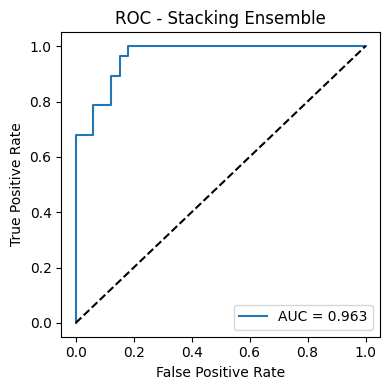

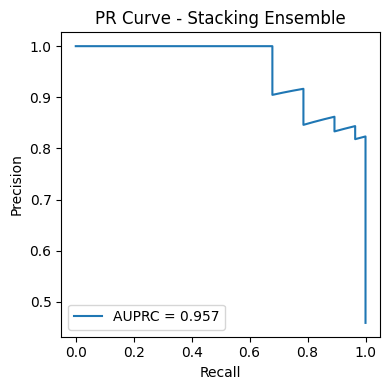

In [28]:
# ============================================================
# 16. STACKING ENSEMBLE
# ============================================================
stacking_clf = StackingClassifier(
    estimators=[
        ("lr", log_reg),
        ("et", best_et),
        ("rf", best_rf),
        ("cb", best_cb),
        ("xgb", xgb_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=-1,
    passthrough=False
)

stacking_clf.fit(X_train, y_train)

y_pred_stack = stacking_clf.predict(X_test)
y_score_stack = stacking_clf.predict_proba(X_test)[:, 1]

print("Stacking Ensemble Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Stacking Ensemble AUC:", roc_auc_score(y_test, y_score_stack))
print("\nStacking Ensemble classification report:\n", classification_report(y_test, y_pred_stack))

plot_roc_curve_generic(y_test, y_score_stack, "ROC - Stacking Ensemble")
plot_pr_curve(y_test, y_score_stack, "PR Curve - Stacking Ensemble")


In [29]:
# ============================================================
# 17. PREPARE DATA FOR ANN AND 1D CNN
# ============================================================
X_train_np = np.asarray(X_train, dtype="float32")
X_test_np = np.asarray(X_test, dtype="float32")
y_train_np = np.asarray(y_train, dtype="float32")
y_test_np = np.asarray(y_test, dtype="float32")

input_dim = X_train_np.shape[1]
print("Input dim:", input_dim)

Input dim: 14


ANN test accuracy: 0.8524590134620667
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


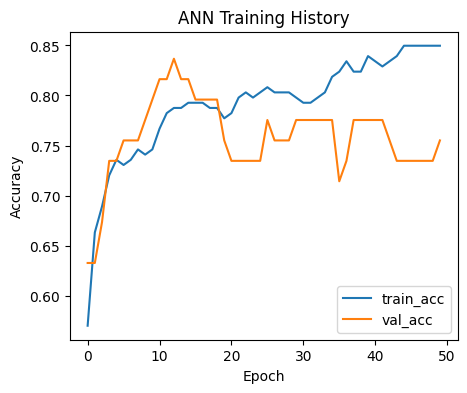

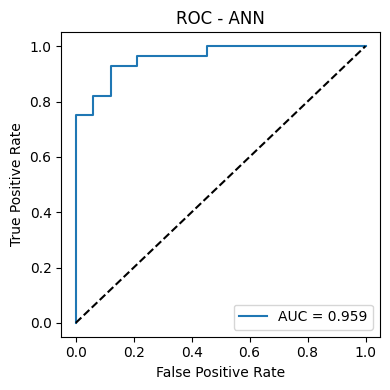

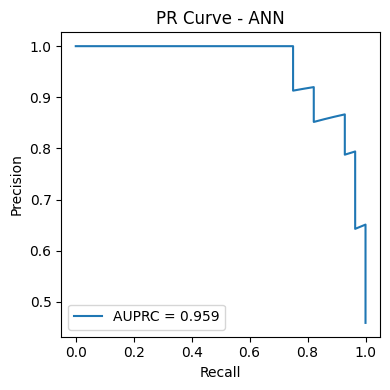

In [30]:
# ============================================================
# 18. FEED-FORWARD ANN
# ============================================================
ann_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_ann = ann_model.fit(
    X_train_np, y_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

ann_loss, ann_acc = ann_model.evaluate(X_test_np, y_test_np, verbose=0)
print("ANN test accuracy:", ann_acc)

y_score_ann = ann_model.predict(X_test_np).ravel()
y_pred_ann = (y_score_ann >= 0.5).astype(int)

# These functions are now defined in Section 8
plot_training_history(history_ann, "ANN Training History")
plot_roc_curve_generic(y_test_np, y_score_ann, "ROC - ANN")
plot_pr_curve(y_test_np, y_score_ann, "PR Curve - ANN")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN test accuracy: 0.8524590134620667
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


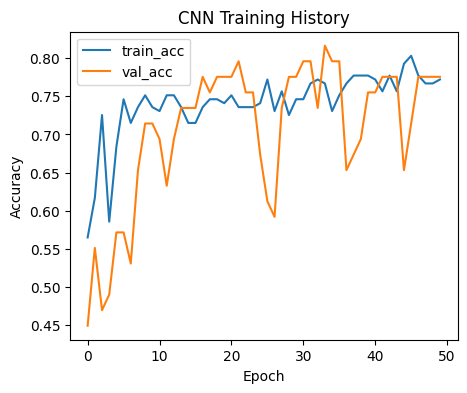

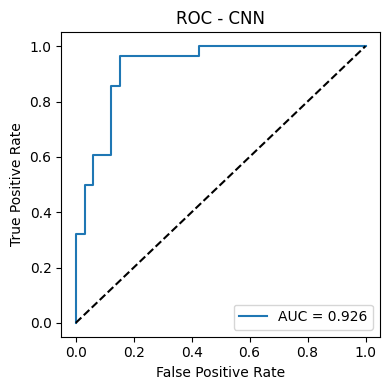

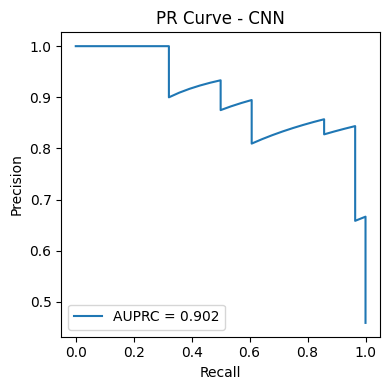

In [31]:
# ============================================================
# 19. 1D CNN ON SELECTED FEATURES
# ============================================================
X_train_cnn = X_train_np.reshape(-1, input_dim, 1)
X_test_cnn = X_test_np.reshape(-1, input_dim, 1)

cnn_model = keras.Sequential([
    layers.Conv1D(32, 3, activation="relu", input_shape=(input_dim, 1)),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 3, activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train_np,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_np, verbose=0)
print("CNN test accuracy:", cnn_acc)

y_score_cnn = cnn_model.predict(X_test_cnn).ravel()
y_pred_cnn = (y_score_cnn >= 0.5).astype(int)

plot_training_history(history_cnn, "CNN Training History")
plot_roc_curve_generic(y_test_np, y_score_cnn, "ROC - CNN")
plot_pr_curve(y_test_np, y_score_cnn, "PR Curve - CNN")



In [32]:
# ============================================================
# 20. FULL PERFORMANCE EVALUATION METRICS
# ============================================================
def compute_binary_metrics(y_true, y_pred, y_score=None, positive_label=1):
    """
    Compute a full set of binary classification metrics.
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, positive_label])
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    recall = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    macro_precision = report_dict["macro avg"]["precision"]
    macro_recall = report_dict["macro avg"]["recall"]
    macro_f1 = report_dict["macro avg"]["f1-score"]

    weighted_precision = report_dict["weighted avg"]["precision"]
    weighted_recall = report_dict["weighted avg"]["recall"]
    weighted_f1 = report_dict["weighted avg"]["f1-score"]

    # Standard deviation across accuracy, precision, recall, f1
    base_metrics = np.array([accuracy, precision, recall, f1], dtype=float)
    sd = float(base_metrics.std())

    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_true, y_score, pos_label=positive_label)
        roc_auc = auc(fpr, tpr)

        pr_precision, pr_recall, _ = precision_recall_curve(y_true, y_score, pos_label=positive_label)
        auprc = auc(pr_recall, pr_precision)
    else:
        roc_auc = None
        auprc = None

    mcr = 1.0 - accuracy

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Specificity": specificity,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1-score": macro_f1,
        "Weighted Precision": weighted_precision,
        "Weighted Recall": weighted_recall,
        "Weighted F1-score": weighted_f1,
        "SD": sd,
        "Kappa": kappa,
        "MCC": mcc,
        "AUC": roc_auc,
        "AUPRC": auprc,
        "MCR": mcr
    }


In [33]:
# ============================================================
# 21. FINAL SUMMARY TABLE WITH ALL METRICS
# ============================================================
summary_rows = []

def add_model_summary(name, y_true, y_pred, y_score=None):
    metrics = compute_binary_metrics(y_true, y_pred, y_score=y_score, positive_label=1)
    row = {"Model": name}
    row.update(metrics)
    summary_rows.append(row)

# Existing models
add_model_summary("Random Forest",                     y_test,     y_pred_rf,      y_score_rf)
add_model_summary("XGBoost",                           y_test,     y_pred_xgb,     y_score_xgb)
add_model_summary("ANN",                               y_test_np,  y_pred_ann,     y_score_ann)
add_model_summary("CNN",                               y_test_np,  y_pred_cnn,     y_score_cnn)
add_model_summary("Logistic Regression (RF features)", y_test,     y_pred_lr,      y_score_lr)
add_model_summary("PCA + Logistic Regression",         y_test_pca, y_pred_lr_pca,  y_score_lr_pca)
add_model_summary("GA + Logistic Regression",          y_test,     y_pred_ga,      y_score_ga)
add_model_summary("SVM",                               y_test,     y_pred_svm,     y_score_svm)
add_model_summary("Naive Bayes",                       y_test,     y_pred_nb,      y_score_nb)
add_model_summary("AdaBoost",                          y_test,     y_pred_ada,     y_score_ada)
add_model_summary("LVQ",                               y_test,     y_pred_lvq,     None)

# New models
add_model_summary("Extra Trees",                       y_test,     y_pred_et,      y_score_et)
add_model_summary("CatBoost",                          y_test,     y_pred_cb,      y_score_cb)
add_model_summary("Voting Ensemble",                   y_test,     y_pred_vote,    y_score_vote)
add_model_summary("Stacking Ensemble",                 y_test,     y_pred_stack,   y_score_stack)

summary_df = pd.DataFrame(summary_rows)

# Sort by Accuracy, descending
summary_df = summary_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)

# Show all columns in Colab output
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(summary_df)

                                Model  Accuracy  Precision    Recall  \
0                     Voting Ensemble  0.918033   0.870968  0.964286   
1                             XGBoost  0.901639   0.843750  0.964286   
2                       Random Forest  0.885246   0.838710  0.928571   
3                   Stacking Ensemble  0.885246   0.862069  0.892857   
4                            CatBoost  0.885246   0.838710  0.928571   
5                                 LVQ  0.885246   0.862069  0.892857   
6           PCA + Logistic Regression  0.885246   0.862069  0.892857   
7                            AdaBoost  0.868852   0.884615  0.821429   
8                         Naive Bayes  0.868852   0.812500  0.928571   
9   Logistic Regression (RF features)  0.868852   0.884615  0.821429   
10           GA + Logistic Regression  0.868852   0.857143  0.857143   
11                                SVM  0.868852   0.857143  0.857143   
12                                ANN  0.852459   0.851852  0.82

In [34]:
# ============================================================
# 21. SUMMARY COMPARISON TABLE (BASELINE VS ALL ML MODELS)
# ============================================================

# Baseline
fram_metrics      = compute_binary_metrics(y_test, y_pred_fram,      y_score_fram)

# Classical / feature-based models
lr_metrics        = compute_binary_metrics(y_test, y_pred_lr,        y_score_lr)        # LogReg RF features
ga_lr_metrics     = compute_binary_metrics(y_test, y_pred_ga,        y_score_ga)        # GA + LR
pca_lr_metrics    = compute_binary_metrics(y_test_pca, y_pred_lr_pca, y_score_lr_pca)   # PCA + LR (note y_test_pca)

svm_metrics       = compute_binary_metrics(y_test, y_pred_svm,       y_score_svm)
nb_metrics        = compute_binary_metrics(y_test, y_pred_nb,        y_score_nb)

# Tree / ensemble models
rf_metrics        = compute_binary_metrics(y_test, y_pred_rf,        y_score_rf)
et_metrics        = compute_binary_metrics(y_test, y_pred_et,        y_score_et)
xgb_metrics       = compute_binary_metrics(y_test, y_pred_xgb,       y_score_xgb)
cb_metrics        = compute_binary_metrics(y_test, y_pred_cb,        y_score_cb)
ada_metrics       = compute_binary_metrics(y_test, y_pred_ada,       y_score_ada)

vote_metrics      = compute_binary_metrics(y_test, y_pred_vote,      y_score_vote)
stack_metrics     = compute_binary_metrics(y_test, y_pred_stack,     y_score_stack)

# Prototype / neural models
lvq_metrics       = compute_binary_metrics(y_test, y_pred_lvq,       None)              # no probabilities

ann_metrics       = compute_binary_metrics(y_test_np, y_pred_ann,    y_score_ann)
cnn_metrics       = compute_binary_metrics(y_test_np, y_pred_cnn,    y_score_cnn)

# Build summary DataFrame
summary = pd.DataFrame({
    "Framingham-like":             fram_metrics,
    "LogReg_RF_feats":            lr_metrics,
    "GA + Logistic Regression":   ga_lr_metrics,
    "PCA + Logistic Regression":  pca_lr_metrics,
    "SVM":                        svm_metrics,
    "Naive Bayes":                nb_metrics,
    "Random Forest":              rf_metrics,
    "Extra Trees":                et_metrics,
    "XGBoost":                    xgb_metrics,
    "CatBoost":                   cb_metrics,
    "AdaBoost":                   ada_metrics,
    "LVQ":                        lvq_metrics,
    "ANN":                        ann_metrics,
    "CNN":                        cnn_metrics,
    "Voting Ensemble":            vote_metrics,
    "Stacking Ensemble":          stack_metrics,
}).T  # models as rows

# Display key metrics
print(summary[["Accuracy", "AUC", "Recall", "Specificity", "MCC"]])

summary_sorted = summary.sort_values("AUC", ascending=False)
summary_sorted[["Accuracy", "AUC", "Recall", "Specificity", "MCC"]]

                           Accuracy       AUC    Recall  Specificity       MCC
Framingham-like            0.688525  0.813853  0.571429     0.787879  0.369442
LogReg_RF_feats            0.868852  0.956710  0.821429     0.909091  0.736117
GA + Logistic Regression   0.868852  0.918290  0.857143     0.878788  0.735931
PCA + Logistic Regression  0.885246  0.964286  0.892857     0.878788  0.769980
SVM                        0.868852  0.969697  0.857143     0.878788  0.735931
Naive Bayes                0.868852  0.976190  0.928571     0.818182  0.745142
Random Forest              0.885246  0.946429  0.928571     0.848485  0.774546
Extra Trees                0.836066  0.948052  0.785714     0.878788  0.669594
XGBoost                    0.901639  0.935065  0.964286     0.848485  0.811017
CatBoost                   0.885246  0.961039  0.928571     0.848485  0.774546
AdaBoost                   0.868852  0.933983  0.821429     0.909091  0.736117
LVQ                        0.885246       NaN  0.892

,Accuracy,AUC,Recall,Specificity,MCC
Naive Bayes,0.868852,0.976190,0.928571,0.818182,0.745142
SVM,0.868852,0.969697,0.857143,0.878788,0.735931
PCA + Logistic Regression,0.885246,0.964286,0.892857,0.878788,0.769980
Stacking Ensemble,0.885246,0.963203,0.892857,0.878788,0.769980
CatBoost,0.885246,0.961039,0.928571,0.848485,0.774546
ANN,0.852459,0.958874,0.821429,0.878788,0.702501
Voting Ensemble,0.918033,0.957792,0.964286,0.878788,0.840350
LogReg_RF_feats,0.868852,0.956710,0.821429,0.909091,0.736117
Extra Trees,0.836066,0.948052,0.785714,0.878788,0.669594
Random Forest,0.885246,0.946429,0.928571,0.848485,0.774546
